# Part1 : Implementing Decoding Strategies

### Implement at least five different decoding strategies. Greedy decoding must be included within the five.
####refer to this [link](httpshttps://huggingface.co/docs/transformers/generation_strategies://)

## Installations
 Install the necessary libraries.

In [ ]:
%%capture
!pip install transformers accelerate bitsandbytes

### Getting access to the model

To load Llama-2, we first need to authenticate ourselves on Hugging Face. This ensures we have the correct permissions to fetch the model.

1. Gain access to the model on Hugging Face: [Link](https://huggingface.co/meta-llama/Llama-2-7b-chat-hf).
2. Use the Hugging Face CLI to login below and verify your authentication status. If you don't already have one, you will need to generate a "read" User Access Token.



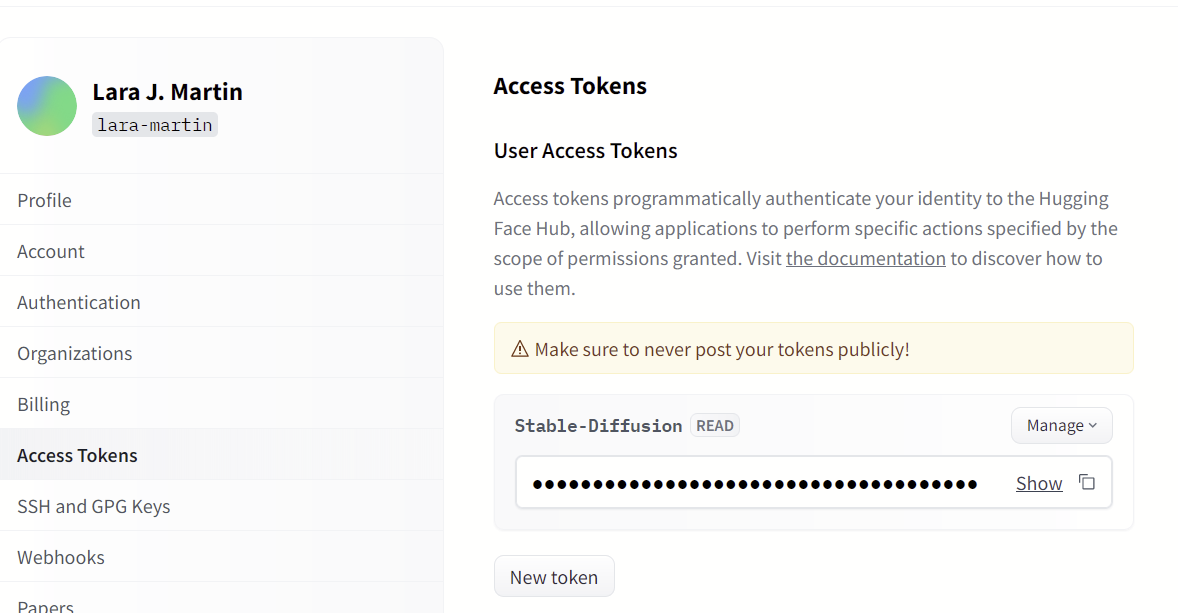

In [ ]:
! git config --global credential.helper store


In [ ]:
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) y
Token is valid (permission: fineGrained).
The token `GenerativeAI` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved in you

In [ ]:
!huggingface-cli whoami

⚠️  Warning: 'huggingface-cli whoami' is deprecated. Use 'hf auth whoami' instead.
tp7048


## Setup the model

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_name = "meta-llama/Llama-2-7b-chat-hf"

You may need to load models over 7B as 4bits due to GPU memory constraints

In [ ]:
# From the Llama-2 Chat Tutorial
# https://colab.research.google.com/drive/1X1z9Q6domMKl2CnEM0QGHNwidLfR4dW2?usp=sharing#scrollTo=THqfvzHIjSK9

quantization_config = BitsAndBytesConfig(load_in_4bit=True) # https://discuss.huggingface.co/t/correct-usage-of-bitsandbytesconfig/33809
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", quantization_config=quantization_config)
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True, use_auth_token=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/tokenization_auto.py:1025: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [ ]:
#your code for implementing 5 different decoding strategies
import torch

def generate(prompt, **kwargs):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    output = model.generate(
        **inputs,
        **kwargs
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)

questions = [
    "What is 37 + 48? Explain step by step.",
    "If a train moves 90 km in 1.5 hours, what is its average speed? Show reasoning.",
    "A store sells apples for $3 each. If Jenny buys 5 apples and pays with $20, how much change does she receive? Explain clearly."
]

decoding_methods = {
    "Greedy": dict(do_sample=False),
    "Beam Search": dict(num_beams=5, early_stopping=True),
    "Top-k Sampling": dict(do_sample=True, top_k=50),
    "Top-p Sampling (Nucleus)": dict(do_sample=True, top_p=0.9),
    "Temperature Sampling": dict(do_sample=True, temperature=0.8)
}

for q in questions:
    print(f"\n=============================\nQUESTION: {q}\n=============================")
    for name, params in decoding_methods.items():
        print(f"\n--- {name} ---")
        result = generate(q, max_new_tokens=120, **params)
        print(result)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



QUESTION: What is 37 + 48? Explain step by step.

--- Greedy ---
What is 37 + 48? Explain step by step. Unterscheidung zwischen einem und einem Satz.

37 + 48 = 85

Here are the steps to calculate 37 + 48:

1. Start with the first number, 37.
2. Add 48 to 37.
3. The result of the addition is 85.

So, 37 + 48 = 85.

--- Beam Search ---
What is 37 + 48? Explain step by step. Hinweis: The answer is not 85.

What is 37 + 48? Explain step by step.Hint: The answer is not 85.

Answer:

Step 1: Add 37 and 48
37 + 48 = 85

Step 2: Check if the answer is correct
85 is not equal to 37 + 48.

Therefore, the answer is incorrect.

--- Top-k Sampling ---
What is 37 + 48? Explain step by step. Unterscheidung zwischen einem und einer (German>English) how to make a good first impression (English>Hindi) 0 0. Community Answer. 37 + 48 = 85. Here's how you can calculate it: 37 + 48 = 85. To get this result, you simply add the two numbers together.

--- Top-p Sampling (Nucleus) ---
What is 37 + 48? Explain

In [ ]:
# Few-shot Prompt
few_shot_prompt = """
You are a math assistant.
Solve the following arithmetic problems step by step.

Example 1:
Question: What is 15 + 27?
Answer:
Step 1: 15 + 20 = 35
Step 2: 35 + 7 = 42
Step 3: 42

Now here is the problem:
Question: What is 37 + 48?
Answer:
"""

print(generate(few_shot_prompt, max_new_tokens=200, do_sample=False))



You are a math assistant.
Solve the following arithmetic problems step by step.

Example 1:
Question: What is 15 + 27?
Answer:
Step 1: 15 + 20 = 35
Step 2: 35 + 7 = 42
Step 3: 42

Now here is the problem:
Question: What is 37 + 48?
Answer:
Step 1: 37 + 40 = 77
Step 2: 77 + 8 = 85
Step 3: 85

Please solve the problem step by step.


In [ ]:
# Chain-of-thought Prompt
cot_prompt = """
Solve the problem using detailed reasoning. Think step by step and explain every part of the solution.

Question: What is 2 * (37 + 47)?
Answer:
"""

print(generate(cot_prompt, max_new_tokens=200, temperature=0.7, do_sample=True))



Solve the problem using detailed reasoning. Think step by step and explain every part of the solution.

Question: What is 2 * (37 + 47)?
Answer:

Step 1: Evaluate the expression inside the parentheses.
37 + 47 = 84

Step 2: Multiply 2 by the result from step 1.
2 * 84 = 168

Therefore, 2 * (37 + 47) = 168.

Explanation:

Step 1: Evaluating the expression inside the parentheses is the first step in solving the problem. In this case, we have 37 + 47. To evaluate this expression, we simply add 37 and 47: 37 + 47 = 84.

Step 2: Now that we have the result of the first step, we can multiply it by 2 to get the final answer. Multiplying 2 by 84 gives us 168.

Therefore, the


## Getting Responses

With everything set up, we can now try out running the model. You can change the `prompt` variable to provide the model with different input.

In [ ]:

prompt1 = 'Your complex QA task'

model_inputs = tokenizer(prompt1, return_tensors="pt").to("cuda:0")

output = model.generate(**model_inputs)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Your complex QA task is our challenge!
 Википедии: The Free Encyclopedia. 2018. C++. (Hozzáférés ideje: 2018. május 22.)
3.  C++ Primer. (Hozzáférés ideje: 2018. május 22.)
4.  C++ Tutorial. (Hozzáférés ideje: 2018. május 22.)
5.  C++ Language. (Hozzáférés ideje: 2018. május 22.)
6.  C++ Standards. (Hozzáférés ideje: 2018. május 22.)
7.  C++ FAQ. (Hozzáférés ideje: 2018. május 22.)

We are ready to help you with your complex QA task! Please provide us with more details about the task, such as the topic, the format of the questions, and any specific requirements or constraints you have.


In [ ]:

prompt2 = 'Your complex QA task '

model_inputs = tokenizer(prompt2, return_tensors="pt").to("cuda:0")

output = model.generate(**model_inputs)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Your complex QA task 
 Begriffe

The following is a list of terms that are commonly used in the field of quality assurance (QA):

1. Quality Assurance (QA): The process of monitoring and improving the quality of a product or service.
2. Quality Control (QC): The process of monitoring and inspecting a product or service to ensure it meets quality standards.
3. Testing: The process of evaluating a product or service to identify any defects or issues.
4. Defect: A flaw or mistake in a product or service that can affect its performance or functionality.
5. Bug: A small error or flaw in a software program that can cause it to malfunction.
6. Edge case: A specific scenario or situation that is unlikely to occur in normal use, but can have a significant impact on the quality of a product or service.
7. User story: A description of a user's goal or task, often used in agile software development to guide the development process.
8. Acceptance criteria: A set of conditions or requirements that m

In [ ]:

prompt3 = 'Your complex QA task '

model_inputs = tokenizer(prompt3, return_tensors="pt").to("cuda:0")

output = model.generate(**model_inputs)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Your complex QA task 101: How to test for 1000+ different scenarios in a single test run
 Unterscheidung von Tests: Why you should test for 1000+ scenarios in a single test run

As a software tester, you've likely encountered the challenge of testing a complex application with multiple features and edge cases. You may have even encountered a situation where you need to test for 1000+ different scenarios in a single test run. This can be a daunting task, but it's essential to ensure that your application is thoroughly tested and free of bugs. In this article, we'll explore the importance of testing for 1000+ scenarios in a single test run and provide some tips on how to accomplish this task.

Why Test for 1000+ Scenarios?
------------------------------

Testing for 1000+ scenarios in a single test run may seem like an unnecessary burden, but there are several reasons why it's important to do so:

### 1. Comprehensive Testing

Testing for a large number of scenarios ensures that your app

# Part2 : The Story Cloze Test
Using the five different decoding strategies you implemented earlier, generate the
5th/final sentence for the story you have chosen. (You should have 5 different generated
outputs for each decoding strategy)

## Getting the Data

In [ ]:
!wget https://raw.githubusercontent.com/lara-martin/NLP-class/main/homeworks/cloze_test_val__winter2018.csv

--2025-11-22 18:36:20--  https://raw.githubusercontent.com/lara-martin/NLP-class/main/homeworks/cloze_test_val__winter2018.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 481528 (470K) [text/plain]
Saving to: ‘cloze_test_val__winter2018.csv’

cloze_test_val__win 100%[===================>] 470.24K  --.-KB/s    in 0.02s   

2025-11-22 18:36:20 (18.9 MB/s) - ‘cloze_test_val__winter2018.csv’ saved [481528/481528]



In [ ]:
import csv

def load_data():
  stories = []
  with open('cloze_test_val__winter2018.csv','r') as in_file:
    reader = csv.reader(in_file)
    for line in reader:
      stories.append(line)
  return stories

raw_stories = load_data()
stories = [(" ".join(story[1:5]), story[5]) if story[-1] =="1" else (" ".join(story[1:5]), story[6]) for story in raw_stories]


In [ ]:
stories #stories is a list of tuples of the 4 starting sentences and the correct ending (start, end)

#### This is a sample code on how you can use the downloaded dataset and generate the 5th sentence. DO NOT USE THIS SAMPLE as you will need to generate the 5th sentence using 5 different decoding strategies.



In [ ]:
# Select story index (1 is typically the first actual story since index 0 is header)
idx = 1
story_start, gold_ending = stories[idx]

print("=== Story Start ===")
print(story_start)
print("\n=== Gold Ending ===")
print(gold_ending)

# Format prompt using chat template for better instruction handling
story_prompt_chat = [
    {"role": "system", "content": "You are a helpful story continuation assistant. Generate a coherent and logical next sentence."},
    {"role": "user", "content": f"Here is the beginning of a story:\n{story_start}\nWrite the next sentence that makes sense:"}
]

prompt = tokenizer.apply_chat_template(story_prompt_chat, tokenize=False, add_generation_prompt=True)

# Decoding strategies
decoding_methods = {
    "Greedy": dict(do_sample=False),
    "Beam Search": dict(num_beams=5, early_stopping=True),
    "Top-k Sampling": dict(do_sample=True, top_k=50),
    "Top-p Sampling (Nucleus)": dict(do_sample=True, top_p=0.9),
    "Temperature Sampling": dict(do_sample=True, temperature=0.8)
}

generated_results = {}

print("\n================ STORY GENERATION RESULTS ================")
for name, params in decoding_methods.items():
    print(f"\n--- {name} ---")

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    output = model.generate(
        **inputs,
        max_new_tokens=60,
        **params
    )
    # extract sentences after notice part
    decoded_text = tokenizer.decode(output[0], skip_special_tokens=True)
    prompt_indicator = "Write the next sentence that makes sense: [/INST]"
    if prompt_indicator in decoded_text:
        generated_sentence = decoded_text.split(prompt_indicator, 1)[-1].lstrip()
    else:
        generated_sentence = decoded_text.split('\n')[-1]
    generated_results[name] = generated_sentence

    print(generated_sentence)


=== Story Start ===
Rick grew up in a troubled household. He never found good support in family, and turned to gangs. It wasn't long before Rick got shot in a robbery. The incident caused him to turn a new leaf.

=== Gold Ending ===
He is happy now.

================ STORY GENERATION RESULTS ================

--- Greedy ---
As he lay in the hospital bed, recovering from his injuries, Rick realized that he needed to make a change in his life and start fresh, away from the familiar surroundings that had led him down the path of danger and violence.

--- Beam Search ---
As he lay in the hospital bed, recovering from his injuries, Rick realized that he didn't want to spend the rest of his life in and out of trouble with the law.

--- Top-k Sampling ---
As he lay in the hospital bed, recovering from his injuries, Rick realized that he didn't want to spend the rest of his life in and out of jail, and he began to think about pursuing a career in social work to help others who were struggling 

#### Evaluate the 5 generated outputs against the gold 5th sentence using at least 2 different evaluation metrics. (BLEU, ROUGE, ...)

You need to download the 'nltk' package to use BLEU score. Implement another generation evaluation metrics.

In [ ]:
pip install rouge-score

In [ ]:
%%capture
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
import pandas as pd

In [ ]:
# Load gold sentence
_, gold_sentence = stories[idx]

gold_tokens = nltk.word_tokenize(gold_sentence.lower())

# ROUGE scorer
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

evaluation_data = []

print("\n================ EVALUATION RESULTS ================\n")

for method, gen_sentence in generated_results.items():
    generated_tokens = nltk.word_tokenize(gen_sentence.lower())

    # BLEU score
    bleu = sentence_bleu([gold_tokens], generated_tokens)

    # ROUGE-L score
    rougeL = scorer.score(gold_sentence, gen_sentence)["rougeL"].fmeasure

    # Save to table
    evaluation_data.append({
        "Decoding Strategy": method,
        "BLEU": round(bleu, 4),
        "ROUGE-L": round(rougeL, 4),
        "Generated Sentence": gen_sentence
    })

# Convert to DataFrame for display
df_eval = pd.DataFrame(evaluation_data)
df_eval



================ EVALUATION RESULTS ================



/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

,Decoding Strategy,BLEU,ROUGE-L,Generated Sentence
0,Greedy,0.0,0.0435,"As he lay in the hospital bed, recovering from..."
1,Beam Search,0.0,0.0541,"As he lay in the hospital bed, recovering from..."
2,Top-k Sampling,0.0,0.0364,"As he lay in the hospital bed, recovering from..."
3,Top-p Sampling (Nucleus),0.0,0.0500,"As he lay in the hospital bed, recovering from..."
4,Temperature Sampling,0.0,0.0435,"As he lay in the hospital bed, recovering from..."
